# Сегментирование клиентов и Кластерный анализ
**Предмет работы:** Сегментирование пользователей страны с ID = 32, определяющее отличительные поведенческие признаки для целевого маркетинга.

**Общие принципы:**
1.  **Подготовка признаков (Feature Engineering):** признаки сформированы на основании истории покупок за 60 дней, которая содержит частоту операций, денежную информацию, характеристики продукта, прочие данные, способствующие отличить предпочтения на уровне потребителя.
2.  **Основной датасет:** Для генерирования кластеров применяется датасет на уровне id клиента (карточки клиентов), куда агрегируются данные транзакций и информация о приобретаемых товарах.
2.  **Сжатие размерности:** Применяется модель **TruncatedSVD**, позволяющая обрабатывать разреженные данные большого объема путем сжатия, одновременно понижая шум.
3.  **Кластеризация:** для кластеризации созданного пространства признаков задействуется метод **K-Means**, определяющий стабильные кластерные образования.
4.  **Составление профайлов кластеров:** происходит путем **анализа относительного среднего**, что позволяет интерпретировать кластеры на наглядном табличном визуальном пространстве

**Набор ключевых инструментов и библиотек:** `sklearn` (SVD, KMeans, Pipeline), `umap`, `matplotlib`.


In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import umap
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_DIR = os.getcwd()
DATA_FOLDER = 'data'

In [3]:
# Создание основного датасета на базе карточки (профайла) клиента df_client_card_filled.csv
file_name = 'df_client_card_filled.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_cluster_basic = (
    pd.read_csv(full_path, index_col='id', dtype={'id': str, 'city':str, 'country':str})
)

# создается список-носитель для добавления датасетов с семьями признаков для проведения кластеризации
# в дальнейшем при анализе к каждому такому датасету семейства можно будет обращаться автономно
dfs = []

### Подготовка признаков (Feature engeneering)

#### Категориальные признаки

Из категориальных признаков составлена разреженная матрица с частотой покупки по каждой категории признака в неделю, которая (матрица) хранится в карточках клиентов
1. **`product_name_*`**: признаки группы наименования продукта
2. **`product_brand_*`**: признаки группы бренда продукта
3. **`basic_colour_*`**: признаки группы цвета продукта
4. **`day_of_week_*`**: признаки дня недели совершенных транзакций

*составление матрицы произведено в файле main.ipynb


In [4]:
# извлечение разреженных категориальных переменных
# в отдельный датасет df_cluster_cat с семейством категориальных признаков
categorical_dict = {}
entropy_list = []
for col_name in ['product_name_', 'product_brand_', 'basic_colour_', 'day_of_week_']:
    mask = df_cluster_basic.columns.str.contains(f'{col_name}')
    categorical_dict[f'{col_name}'] = df_cluster_basic.columns[mask][4:-1].to_numpy()
    # дополнительно создается список для подсчета энтропии (см далее) для каждого категориального признака
    entropy_list += [df_cluster_basic.columns[mask][-1]]
cat_feats = np.concatenate(list(categorical_dict.values()))
df_cluster_cat = df_cluster_basic[cat_feats]


dfs += [df_cluster_cat]
df_cluster_cat

,product_name_адаптер,product_name_адаптеры,product_name_аквагрим,product_name_аквагримм,product_name_аккумулятор,product_name_альфа-липоевая,product_name_аминокислота,product_name_аминокислоты,product_name_анорак,product_name_антифог,...,basic_colour_unknown,basic_colour_white,basic_colour_yellow,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,day_of_week_7
id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000000,0.000000,0.0,0.666667,0.000000,0.000000,0.000,0.000000,0.333333,0.000000
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.125,0.0,...,0.000000,0.000000,0.0,0.375000,0.125000,0.500000,0.000,0.000000,0.000000,0.000000
1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000000,0.000000,0.0,0.000000,0.166667,0.166667,0.000,0.000000,0.166667,0.500000
10000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.250000,0.000000,0.0,0.000000,0.125000,0.375000,0.125,0.000000,0.375000,0.000000
100000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.166667,0.000000,0.0,0.500000,0.166667,0.000000,0.000,0.333333,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.333333,0.000000,0.0,0.200000,0.066667,0.066667,0.200,0.066667,0.266667,0.133333
99994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000,0.500000,0.500000,0.000000
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000000,0.142857,0.0,0.000000,0.428571,0.000000,0.000,0.428571,0.142857,0.000000


Для каждого категориального признака извлекается энтропия (`product_name_entropy`, `product_brand_entropy`, `basic_colour_entropy`, `day_of_week_entropy`), позволяющая модели понять, насколько разнообразны предпочтения для отдельно взятого клиента*

*подсчет энтропии осуществлен в блокноте main.ipynb


In [5]:
df_cluster_entrop = df_cluster_basic[entropy_list]
dfs += [df_cluster_entrop]
df_cluster_entrop

,product_name_entropy,product_brand_entropy,basic_colour_entropy,day_of_week_entropy
id,,,,
0,1.098612,0.636514,1.098612,0.636514
100,1.906155,2.079442,1.213008,0.974315
1000,1.329661,1.560710,1.560710,1.242453
10000,1.732868,1.073543,1.732868,1.255482
100000,1.329661,1.242453,1.329661,1.011404
...,...,...,...,...
99993,1.450252,2.211069,1.547287,1.806507
99994,0.693147,0.693147,0.693147,0.693147
99996,1.747868,1.277034,1.945910,1.004242


#### Агрегирование числовых признаков на основании 60-дневных данных о транзакциях

Загрузка и дополнение датасета с продажами df_purchases дополнительными признаками:
1. **`a_abs`**: абсолютная мощность цветовой оси _"зеленый - красный"_
2. **`b_abs`**: абсолютная мощность цветовой оси _"синий - желтый"_
3. **`cost_md`**: стоимость товара со скидкой (0, если в транзакции участвовал товар без скидки)
4. **`cost_fp`**: стоимость товара со без скидки (0, если в транзакции участвовал товар со скидкой)

In [6]:
file_name = 'df_purchases.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)

df_purchases = pd.read_csv(full_path, dtype={'id': str, 'city':str, 'country':str})

# добавление колонок абсолютных значений 'a' и 'b', характеризующих абсолютную мощность этих цветовых осей
df_purchases.insert(
    loc=df_purchases.columns.get_loc('b') + 1,
    column='b_abs',
    value=np.abs(df_purchases['b'])
)

df_purchases.insert(
    loc=df_purchases.columns.get_loc('b') + 1,
    column='a_abs',
    value=np.abs(df_purchases['a'])
)

# разделение продаж на продажи по маркетинговому промо и продажи без промо - величины стоимости, разреженные на уровне флага наличия промо 'base_sale'
df_purchases.insert(
    loc=df_purchases.columns.get_loc('base_sale') + 1,
    column='cost_md',
    value=df_purchases['base_sale'] * df_purchases['cost']
)

df_purchases.insert(
    loc=df_purchases.columns.get_loc('base_sale') + 1,
    column='cost_fp',
    value=(df_purchases['base_sale'] != 1) * df_purchases['cost']
)

In [7]:
df_purchases

,id,product,colour,cost,product_sex,base_sale,cost_fp,cost_md,dt,week,...,is_colour_block,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls,product_brand,product_name,gender
0,0,"Велосипед горный женский Stern Mira 2.0 26""",белый/синий,13599,0.0,1,0,13599,7,2,...,1,1,0,0,1,0,0,stern,велосипед,0.0
1,0,Стол Outventure,зелёный,1499,NaN,0,1499,0,37,7,...,0,0,0,0,0,0,0,outventure,стол,0.0
2,0,Набор Outventure: стол + 4 стула,бежевый,4799,NaN,0,4799,0,37,7,...,0,0,0,0,0,0,0,outventure,набор,0.0
3,3,Бутсы мужские GSD Astro,белый,1599,1.0,0,1599,0,13,3,...,0,1,0,1,0,0,0,gsd,бутсы,1.0
4,3,Мяч футбольный PUMA TEAMFINAL 21.2 FIFA QUALIT...,мультицвет,7199,NaN,0,7199,0,27,5,...,0,0,0,0,0,0,0,puma,мяч,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786255,178004,Полуботинки мужские Ascot Vortex,хаки/черный,7999,1.0,0,7999,0,12,3,...,1,1,0,1,0,0,0,ascot,полуботинки,1.0
786256,178004,Кроссовки мужские Nike Air Max 90,черный/серый,24299,1.0,0,24299,0,13,3,...,1,1,0,1,0,0,0,nike,кроссовки,1.0
786257,178004,Кроссовки мужские Nike Air Max 90,черный/серый,24299,1.0,0,24299,0,20,4,...,1,1,0,1,0,0,0,nike,кроссовки,1.0
786258,178004,Пакет,коричневый,12,NaN,0,12,0,20,4,...,0,0,0,0,0,0,0,noname,пакет,1.0


Составление датасета для семейства гендерных признаков продукта, агрегированных по среднему на уровне отдельного покупателя:
1. **`prod_adults`**: частота попадания в транзакции товаров для взрослых (0...1)
2. **`prod_kids`**: частота попадания в транзакции товаров для детей (0...1)
3. **`prod_men`**: частота попадания в транзакции товаров для мужчин (0...1)
4. **`prod_women`**: частота попадания в транзакции товаров для женщин (0...1)
5. **`prod_boys`**: частота попадания в транзакции товаров для мальчиков (0...1)
6. **`prod_girls`**: частота попадания в транзакции товаров для девочек (0...1)


In [8]:
prod_gend_list = ['id', 'prod_adults', 'prod_kids', 'prod_men',
       'prod_women', 'prod_boys', 'prod_girls'] # 'gender'

df_cluster_prod_gender = (
    df_purchases[prod_gend_list]
    .groupby('id', sort=False)
    .mean()
)

dfs += [df_cluster_prod_gender]
df_cluster_prod_gender

,prod_adults,prod_kids,prod_men,prod_women,prod_boys,prod_girls
id,,,,,,
0,0.333333,0.000000,0.000000,0.333333,0.000000,0.000000
3,0.750000,0.000000,0.750000,0.000000,0.000000,0.000000
4,0.000000,0.857143,0.000000,0.000000,0.000000,0.285714
6,0.600000,0.400000,0.600000,0.000000,0.266667,0.000000
7,0.384615,0.384615,0.000000,0.384615,0.384615,0.000000
...,...,...,...,...,...,...
177998,0.750000,0.250000,0.000000,0.750000,0.000000,0.000000
177999,0.181818,0.090909,0.181818,0.000000,0.000000,0.000000
178001,0.909091,0.000000,0.909091,0.000000,0.000000,0.000000


Составление датасета для семейства признаков потребительского поведения, агрегированных по среднему на уровне отдельного покупателя:

*   **`n_purchases`**: Общее количество покупок в штуках, совершенных клиентом за наблюдаемый период.
*   **`cost_sum`**: Суммарная стоимость всех покупок клиента в деньгах (общая выручка).
*   **`cost_mean`**: Средний чек (средняя стоимость одной купленной вещи).
*   **`avg_basket_money`**: Средняя стоимость корзины (чека) в денежном выражении. (Прим.: за отсутствием дополнительной информации, принимается, что покупки одного клиента в течение одного дня есть один чек для этого клиента).
*   **`avg_basket_quant`**: Среднее количество товаров в одной корзине (глубина чека).
*   **`cost_std`**: Стандартное отклонение стоимости покупок. Показывает вариативность трат (стабильность/нестабильность поведения).
*   **`base_sale_mean`**: Средняя величина базовой скидки (без учета промоакций).
*   **`base_sale_sum`**: Суммарный объем полученных базовых скидок.
*   **`cost_fp_mean`**: Средняя стоимость покупок по полной цене (Full Price).
*   **`cost_md_mean`**: Средняя стоимость покупок товаров с уценкой (Mark Down).
*   **`count_md_vs_fp`**: Отношение количества уцененных товаров (MD) к товарам по полной цене (FP). Выступает как индикатор чувствительности к скидкам.
*   **`cost_sum_md_share`**: Доля затрат на уцененные товары в общем объеме трат (в %).
*   **`cost_mean_md_vs_fp`**: Отношение среднего чека MD к среднему чеку FP.
*   **`cost_md_sum`**: Суммарная стоимость всех купленных уцененных товаров.
*   **`dt_nunique`**: Количество уникальных дат посещения (дней, когда совершались покупки). Характеризует регулярность визитов.



In [9]:
df_cluster_discount = (
    df_purchases
    .groupby('id', sort=False)
    .agg({
        'cost':['count', 'sum', 'mean', 'std'],            # сумма покупок
        'base_sale':['mean', 'sum'],        # количество покупок со скидкой
        'cost_fp': 'mean',
        'cost_md': ['mean', 'sum'],
        'dt':'nunique',         # для подсчета среднего количества дней визитов за период (частоты визитов)
    })
    .fillna(0)                  # устранение возможных nan в cost_std
)

# переименовывание колонок (избавление от мультииндекса)
df_cluster_discount.columns = [f'{i[0]}_{i[1]}' for i in df_cluster_discount.columns]
#df_cluster_discount.columns = df_cluster_discount.columns.str.strip('_')
df_cluster_discount.rename(columns={'cost_count': 'n_purchases'}, inplace=True)

# вычисление ср количества единиц в чеке
df_cluster_discount.insert(
    loc=df_cluster_discount.columns.get_loc('cost_mean') + 1,
    column='avg_basket_quant',
    value=df_cluster_discount['n_purchases'] / df_cluster_discount['dt_nunique']
)

# вычисление средней корзины
df_cluster_discount.insert(
    loc=df_cluster_discount.columns.get_loc('cost_mean') + 1,
    column='avg_basket_money',
    value=df_cluster_discount['cost_sum'] / df_cluster_discount['dt_nunique']
)

# вычисление соотношения средних сумм покупок по полной стоимости к покупкам по скидке
df_cluster_discount.insert(
    loc=df_cluster_discount.columns.get_loc('cost_md_mean') + 1,
    column='cost_mean_md_vs_fp',
    value=df_cluster_discount['cost_md_mean'].div(df_cluster_discount['cost_fp_mean'], axis=0).replace(np.inf, 0)
)

# вычисление доли общих покупок по распродаже ко всем покупкам клиента
df_cluster_discount.insert(
    loc=df_cluster_discount.columns.get_loc('cost_md_mean') + 1,
    column='cost_sum_md_share',
    value=df_cluster_discount['cost_md_sum'].div(df_cluster_discount['cost_sum'], axis=0).replace(np.inf, 0)
)

# вычисление соотношения количества товаров, приобретенных со скидкой к кол-ву товаров, приобретенных по полн ст
df_cluster_discount.insert(
    loc=df_cluster_discount.columns.get_loc('cost_md_mean') + 1,
    column='count_md_vs_fp',
    value=(1 / (df_cluster_discount['n_purchases'] / df_cluster_discount['base_sale_sum'] - 1)).replace(np.inf, 0)
)

dfs += [df_cluster_discount]
df_cluster_discount

,n_purchases,cost_sum,cost_mean,avg_basket_money,avg_basket_quant,cost_std,base_sale_mean,base_sale_sum,cost_fp_mean,cost_md_mean,count_md_vs_fp,cost_sum_md_share,cost_mean_md_vs_fp,cost_md_sum,dt_nunique
id,,,,,,,,,,,,,,,
0,3,19897,6632.333333,9948.500000,1.500000,6254.864773,0.333333,1,2099.333333,4533.000000,0.500000,0.683470,2.159257,13599,2
3,4,14596,3649.000000,4865.333333,1.333333,2446.085308,0.250000,1,2949.250000,699.750000,0.333333,0.191765,0.237264,2799,3
4,7,31093,4441.857143,7773.250000,1.750000,2946.103157,0.000000,0,4441.857143,0.000000,0.000000,0.000000,0.000000,0,4
6,15,84085,5605.666667,9342.777778,1.666667,5931.014930,0.400000,6,4436.066667,1169.600000,0.666667,0.208646,0.263657,17544,9
7,13,58827,4525.153846,7353.375000,1.625000,2835.576186,0.384615,5,2953.230769,1571.923077,0.625000,0.347375,0.532272,20435,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177998,8,20732,2591.500000,6910.666667,2.666667,1332.417245,0.750000,6,562.250000,2029.250000,3.000000,0.783041,3.609160,16234,3
177999,11,148289,13480.818182,37072.250000,2.750000,11522.310374,0.181818,2,9308.272727,4172.545455,0.222222,0.309517,0.448262,45898,4
178001,11,48289,4389.909091,6036.125000,1.375000,2918.717028,0.090909,1,4308.181818,81.727273,0.100000,0.018617,0.018970,899,8


Вычисление признаков предпочтений клиента по цветовым модификаторам (среднее по бинарным флагам)
*   **`is_bright`**: Признак покупки товаров **ярких** цветов
*   **`is_dark`**: Признак предпочтения **тёмных** тонов. Ассоциируется с консервативным или практичным стилем.
*   **`is_iridescent`**: Признак покупки товаров с эффектом **перелива** или "хамелеон".
*   **`is_light`**: Признак предпочтения **светлых** оттенков.
*   **`is_multicolored`**: Признак покупки **разноцветных** товаров.
*   **`is_neutral`**: Признак выбора **нейтральной** гаммы (естественные, земляные тона), которые легко сочетаются с другими вещами.
*   **`is_pastel`**: Признак покупки товаров **пастельных** тонов (нежно-розовый, мятный, небесно-голубой).
*   **`is_rare`**: Признак выбора **редких/уникальных** цветов (сложные оттенки, не входящие в стандартную палитру). Индикатор "модников" или поиска эксклюзива.
*   **`is_saturated`**: Признак покупки товаров **насыщенных**, глубоких цветов (не неон, но интенсивный пигмент).
*   **`is_texture`**: Признак интереса к **фактурным** цветам (где цвет задается материалом/текстурой или принтом).
*   **`is_uncertain`**: Признак покупки товаров с **неопределенным/смешанным** цветом, сложным для однозначной классификации.
*   **`is_colour_block`**: Признак покупки вещей в стиле **цветовой блок** (крупные блоки разных цветов на одном изделии).


In [10]:
color_modif_list = ['is_bright', 'is_dark', 'is_iridescent',
       'is_light', 'is_multicolored', 'is_neutral', 'is_pastel', 'is_rare',
       'is_saturated', 'is_texture', 'is_uncertain',
       'is_colour_block']

df_cluster_color_modif = (
    df_purchases
    .groupby('id', sort=False)
    .agg({c:['mean', 'std'] for c in color_modif_list})
    .fillna(0)                  # устранение возможных nan в _std
)

# переименовывание колонок (избавление от мультииндекса)
df_cluster_color_modif.columns = [f'{i[0]}_{i[1]}' for i in df_cluster_color_modif.columns]
#df_cluster_color_modif.columns = df_cluster_color_modif.columns.str.strip('_')

dfs += [df_cluster_color_modif]
df_cluster_color_modif

,is_bright_mean,is_bright_std,is_dark_mean,is_dark_std,is_iridescent_mean,is_iridescent_std,is_light_mean,is_light_std,is_multicolored_mean,is_multicolored_std,...,is_rare_mean,is_rare_std,is_saturated_mean,is_saturated_std,is_texture_mean,is_texture_std,is_uncertain_mean,is_uncertain_std,is_colour_block_mean,is_colour_block_std
id,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.000000,0.166667,0.288675,0.0,0.0,0.500000,0.500000,0.000000,0.000000,...,0.0,0.0,0.500000,0.500000,0.0,0.0,0.000000,0.000000,0.333333,0.577350
3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.500000,0.577350,0.250000,0.500000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.250000,0.500000,0.000000,0.000000
4,0.000000,0.000000,0.071429,0.188982,0.0,0.0,0.500000,0.408248,0.142857,0.377964,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.285714,0.487950,0.428571,0.534522
6,0.033333,0.129099,0.755556,0.332539,0.0,0.0,0.088889,0.187577,0.000000,0.000000,...,0.0,0.0,0.255556,0.366595,0.0,0.0,0.066667,0.258199,0.333333,0.487950
7,0.217949,0.381181,0.256410,0.433629,0.0,0.0,0.384615,0.463404,0.000000,0.000000,...,0.0,0.0,0.371795,0.462250,0.0,0.0,0.076923,0.277350,0.230769,0.438529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177998,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.750000,0.462910,0.000000,0.000000,...,0.0,0.0,0.250000,0.462910,0.0,0.0,0.000000,0.000000,0.125000,0.353553
177999,0.045455,0.150756,0.409091,0.490825,0.0,0.0,0.136364,0.323335,0.090909,0.301511,...,0.0,0.0,0.181818,0.404520,0.0,0.0,0.272727,0.467099,0.181818,0.404520
178001,0.000000,0.000000,0.590909,0.490825,0.0,0.0,0.045455,0.150756,0.000000,0.000000,...,0.0,0.0,0.363636,0.504525,0.0,0.0,0.272727,0.467099,0.090909,0.301511


Вычисление параметров цвета в покупках. Данные признаки основаны на математическом представлении цвета товаров (пространства CIELAB и полярных координат) они описывают цифровые характеристики цветовых предпочтений:

**Пространство CIELAB (Светлота и цветоощущение):**
*   **`L_mean`**: Средняя светлота (Lightness) купленных товаров. Чем выше показатель, тем светлее гардероб/покупки клиента (от 0 — абсолютно черный до 100 — чистый белый).
*   **`L_std`**: Стандартное отклонение светлоты. Показывает, насколько разнообразны покупки по светлоте (сочетает ли клиент очень светлые и очень темные вещи).
*   **`a_mean`**: Среднее значение оси **a** (зелено-красная ось). Отрицательные значения смещены к зеленому, положительные — к красному/пурпурному.
*   **`a_std`**: Дисперсия (разнообразие) покупок по зелено-красной оси.
*   **`b_mean`**: Среднее значение оси **b** (сине-желтая ось). Отрицательные смещены к синему, положительные — к желтому.
*   **`b_std`**: Дисперсия (разнообразие) покупок по сине-желтой оси.
*   **`a_abs_mean` & `b_abs_mean`**: Относительная интенсивность отклонения от нейтрального серого. Высокие значения говорят о выборе одежды с выраженным цветовым пигментом (отказ от ахроматических цветов по соответствующим осям).

**Насыщенность и Цветовой тон (Chroma & Hue):**
*   **`chroma_std`**: Дисперсия чистоты/красочности цвета (Chroma). Показывает, миксует ли клиент приглушенные (сероватые) и чистые (кричащие) цвета в своих покупках.
*   **`hue_cos_mean` и `hue_sin_mean`**: Косинус и синус цветового тона (угла на цветовом круге). Использование тригонометрических функций необходимо для корректного усреднения циклических величин (чтобы среднее между красным в 350 град и красным в 10 град было корректным, а не 180 град).
*   **`hue_concentration`**: Уровень концентрации (или кучности) цветового тона. Высокое значение означает, что клиент покупает товары очень близких оттенков на цветовом круге (например, только синие и голубые). Низкое значение — клиент берет цвета из противоположных спектров.
*   **`saturation_mean`**: Средняя насыщенность цвета. Высокая насыщенность — "сочные" цвета, низкая — блеклые, приближенные к оттенкам серого.
*   **`saturation_std`**: Разброс покупок клиента по параметру насыщенности (выбирает строго блеклые или разбавляет их яркими акцентами).


In [11]:
df_cluster_color = (
    df_purchases
    .groupby('id', sort=False)
    .agg({
        'L': ['mean', 'std'],
        'a': ['mean', 'std'],
        'b': ['mean', 'std'],
        'a_abs': 'mean',
        'b_abs': 'mean',
        'chroma': ['mean', 'std'],
        'hue_cos': 'mean',      # можно добавить абсолютную концентрацию оттенка np.sqrt(['hue_cos']**2 + ['hue_sin']**2)
        'hue_sin': 'mean',      # можно добавить абсолютную концентрацию оттенка np.sqrt(['hue_cos']**2 + ['hue_sin']**2)
        'saturation': ['mean', 'std'], # либо saturation, либо 'is_saturated' - их корреляция = 0.964938
     })
    .fillna(0)                  # устранение возможных nan в _std
)

# переименовывание колонок (избавление от мультииндекса)
df_cluster_color.columns = [f'{i[0]}_{i[1]}' for i in df_cluster_color.columns]
#df_cluster_color.columns = df_cluster_color.columns.str.strip('_')

# добавление фичи абсолютная концентрация оттенка
s_conc = np.sqrt(df_cluster_color['hue_cos_mean']**2 + df_cluster_color['hue_sin_mean']**2)
df_cluster_color.insert(df_cluster_color.columns.get_loc('hue_sin_mean') + 1, 'hue_concentration', s_conc)

dfs += [df_cluster_color]
df_cluster_color

,L_mean,L_std,a_mean,a_std,b_mean,b_std,a_abs_mean,b_abs_mean,chroma_mean,chroma_std,hue_cos_mean,hue_sin_mean,hue_concentration,saturation_mean,saturation_std
id,,,,,,,,,,,,,,,
0,69.441543,25.023842,-5.434027,45.657737,2.674626,52.543237,31.828406,38.625508,50.505777,32.780237,0.083333,0.433013,0.440959,0.534014,0.449945
3,75.896253,27.871064,-0.001596,0.001160,0.003025,0.002199,0.001596,0.003025,0.003420,0.002486,0.750000,0.000000,0.750000,0.000000,0.000000
4,67.251129,21.116574,6.896923,9.497804,0.952737,1.309008,6.898185,0.952737,6.964534,9.586240,0.709523,-0.051951,0.711422,0.070588,0.097192
6,22.253462,22.643972,16.928496,29.570970,-11.093108,44.873743,18.365639,24.859139,31.339692,47.693717,0.666667,-0.115470,0.676593,0.255556,0.366595
7,57.222586,38.420945,11.674818,29.012886,29.288274,39.774417,18.308010,29.288274,39.128475,46.520588,0.814103,0.144338,0.826799,0.383430,0.463104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177998,84.455613,25.206164,-1.510772,24.769767,-1.582211,31.462661,12.465096,17.074415,21.416446,32.935122,0.384982,-0.005179,0.385017,0.225050,0.376829
177999,40.810895,28.948790,-0.508273,23.147196,2.701366,16.282617,9.882636,6.371844,17.083680,37.028776,0.423272,0.056299,0.426999,0.193083,0.400657
178001,34.061288,18.808675,28.299431,40.375322,-39.742051,54.029580,29.290089,39.742559,49.375477,66.977220,0.092404,-0.326481,0.339306,0.374901,0.496920


Добавление персонального коэффициента клинента **`personal_coef`** - метрики рассчитываемой внутри компании

In [12]:
file_name = 'df_coeffs_filled.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)
df_cluster_coeffs =pd.read_csv(full_path, usecols=['id', 'personal_coef'], index_col='id', dtype={'id': str})

dfs += [df_cluster_coeffs]
df_cluster_coeffs

,personal_coef
id,
0,0.5072
100,0.5584
1000,0.5072
10000,0.5072
100000,0.5072
...,...
99993,0.4304
99994,0.4304
99996,0.5072


In [13]:
# проверка состава dfs
[df.columns[0] for df in dfs]

['product_name_адаптер',
 'product_name_entropy',
 'prod_adults',
 'n_purchases',
 'is_bright_mean',
 'L_mean',
 'personal_coef']

In [14]:
# кластеры будут расcчитаны только для страны с ID = 32
ind = df_cluster_basic.index[df_cluster_basic['country'] != '32']

# создание итогового датасета  df_cluster со всеми признаками, необходимыми для кластеризации и последующего анализа
df_cluster = pd.concat(dfs, axis=1).drop(ind)

df_cluster

,product_name_адаптер,product_name_адаптеры,product_name_аквагрим,product_name_аквагримм,product_name_аккумулятор,product_name_альфа-липоевая,product_name_аминокислота,product_name_аминокислоты,product_name_анорак,product_name_антифог,...,a_abs_mean,b_abs_mean,chroma_mean,chroma_std,hue_cos_mean,hue_sin_mean,hue_concentration,saturation_mean,saturation_std,personal_coef
id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,31.828406,38.625508,50.505777,32.780237,0.083333,4.330127e-01,0.440959,0.534014,0.449945,0.5072
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.125,0.0,...,9.754072,11.835813,20.014718,23.564180,0.357761,1.756257e-01,0.398544,0.283634,0.283057,0.5584
1000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,37.805369,49.084655,62.450990,60.404008,0.131347,-7.602431e-02,0.151762,0.546552,0.500136,0.5072
10000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,16.634032,18.807208,25.612127,48.137631,0.500000,2.775558e-17,0.500000,0.230937,0.403460,0.5072
100000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,5.197635,18.646839,19.611092,32.567884,0.595079,1.886272e-01,0.624259,0.236338,0.391593,0.5072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,11.166252,16.169897,20.004095,31.353183,0.404393,-5.177344e-02,0.407694,0.244444,0.382487,0.4304
99994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,39.592795,53.928650,66.902083,94.613834,0.250000,-4.330127e-01,0.500000,0.500000,0.707107,0.4304
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,...,25.027946,33.540813,42.111570,52.670757,0.297122,-5.918789e-03,0.297181,0.388628,0.471797,0.5072


### Предобработка данных и снижение размерности (SVD)

Поскольку матрица категориальных признаков разрежена - они представлены в one-hot (покатегорийном) виде и имеют высокую размерность - используется метод снижения размерности TruncatedSVD, разработанный специально для разреженных данных (в отличие от PCA, который требует центрирования плотных данных). Сжатие до 100 компонент (`n_components`=100) позволяет:
1. Избежать "проклятия размерности", когда расстояния между точками размываются.
2. Эффективно сжать данные с сохранением максимума полезной дисперсии.
3. Избавиться от информационного «шума».

In [15]:
# определение списка разреженных признаков из семейства df_cluster_cat
sparse_feats = df_cluster_cat.columns.to_numpy()

# определение списка обычных признаков путем исключения разреженных из общего списка
dense_feats = np.concatenate([df.columns.tolist() for df in dfs])
dense_feats = dense_feats[~np.isin(dense_feats, sparse_feats)]

In [16]:
sparse_pipe = Pipeline([
    ('decomposer', TruncatedSVD(n_components=100, random_state=42)),
    ('scaler', StandardScaler()),
])

preprocess = ColumnTransformer(
    [
        ('sparce_features', sparse_pipe, sparse_feats),
        ('dense_features', StandardScaler(), dense_feats),
    ],
    remainder='drop'
)

### Визуализация многомерных данных (UMAP и t-SNE)

Создается упрощенная проекция многомерного пространства клиентов на 2D-плоскость для визуальной оценки качества разбиения.

**Обоснование:**
*   Поскольку модель K-Means ищет кластеры в многомерном пространстве объектов, результаты невозможно визуализировать напрямую.
*   **t-SNE** и **UMAP** - нелинейные алгоритмы, предназначенные специально для визуализации форм большой размерности. Они аккуратно "разворачивают" многомерные формы, ориентируя их на двумерное пространство, сохраняя расстояния между ближайшими соседями, при этом глобальная плотность данных искажается.
*   UMAP и t-SNE используется *строго для визуализации* уже готовых кластерных лейблов K-Means (`X_reduced`, `X_tsne`) - полученные сжатия посредством данных алгоритмов не передаются на вход кластеризатору.


In [17]:
X = preprocess.fit_transform(df_cluster)

In [18]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
X_reduced = reducer.fit_transform(X)

/opt/anaconda3/envs/test/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [19]:
reducer_tsne = TSNE(n_components=2)
X_tsne = reducer_tsne.fit_transform(X)

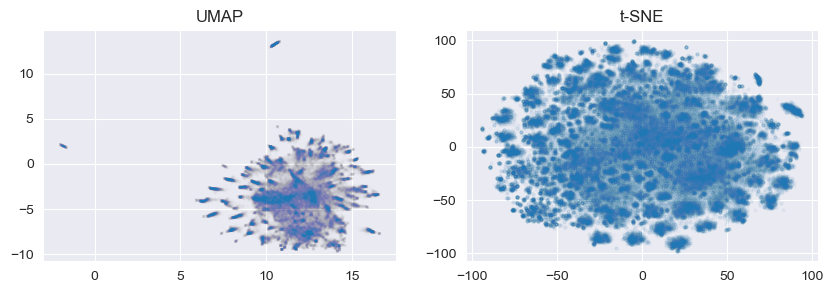

In [20]:
_, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[1].scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, alpha=0.02)
ax[1].set_title('t-SNE')
ax[0].scatter(X_reduced[:, 0], X_reduced[:, 1], s=2, alpha=0.002)
ax[0].set_title('UMAP')
plt.show()

В целом можно говорить о сферической природе данных, поэтому, имея в распоряжении признаки преимущественно числовые, для кластеризации можно применить метод из семейства K-Means, а именно: более продвинутый вариант K-Means++.

### Определение оптимального числа кластеров (K)

Подбор наилучшего гиперпараметра `k` для алгоритма K-Means.

**Обоснование:**
*   Архитектура метода K-Means требует заранее указать желаемое количество групп. Для поиска оптимального баланса протестирован набор из нескольких значений `k`
*   **Логика выбора:** получение высокой детализации, одновременно избегая избыточного дробления (микро-кластеры не имеют маркетинговой ценности). Оценка ведется на основе метрик формы и плотности (Silhouette score / метрика инерции) в совокупности с долей представленных кластеров для каждого набора кластеров.


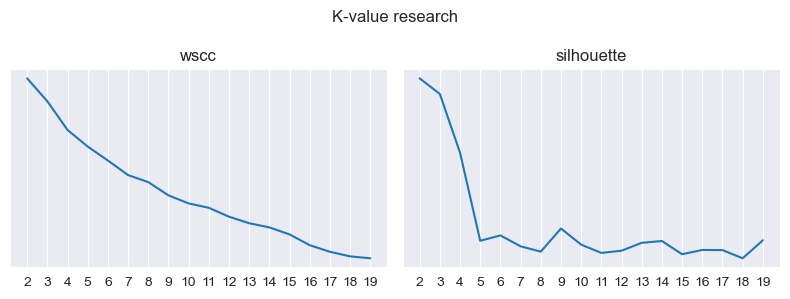

In [21]:
# размерность пространства признаков сокращено до 25% случайным образом в целях ускорения времени обработки данных
X_shortened = X[np.random.choice(X.shape[0], size=int(X.shape[0]*.25))]

right_edge = 20
wscc = []
silhouette = []
n_clusters_list = range(2, right_edge)
for k in n_clusters_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_shortened)
    wscc += [kmeans.inertia_]
    silhouette += [silhouette_score(X_shortened, kmeans.labels_)]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
fig.suptitle('K-value research')
ax[0].plot(n_clusters_list, wscc)
ax[1].plot(n_clusters_list, silhouette)
ax[0].set_title('wscc')
ax[1].set_title('silhouette')
for a in ax:
    a.set_xticks(list(n_clusters_list))
    a.set_yticks([])
plt.tight_layout();

Поскольку метрики не дают однозначного ответа, поиск параметра k продолжается экспериментальным путем по размерам выборочных кластеров, определенных по точкам изломов графика Silhouette

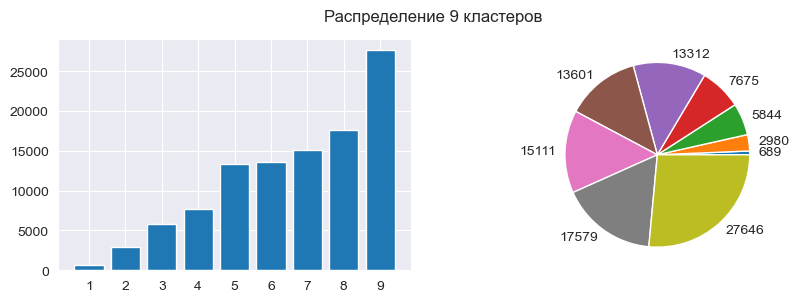

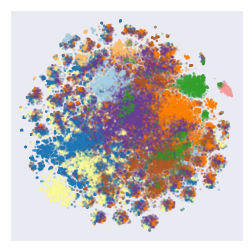

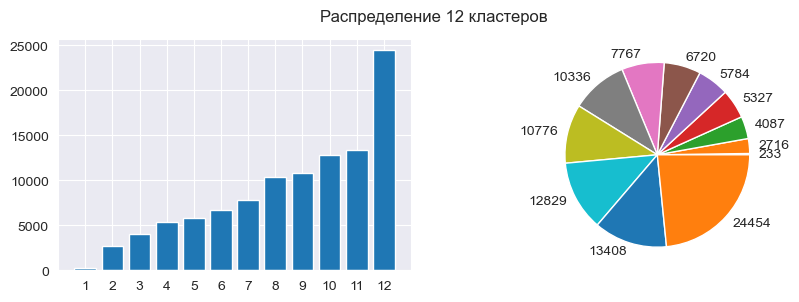

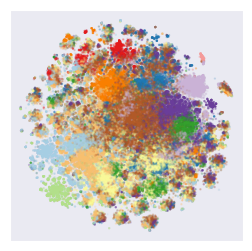

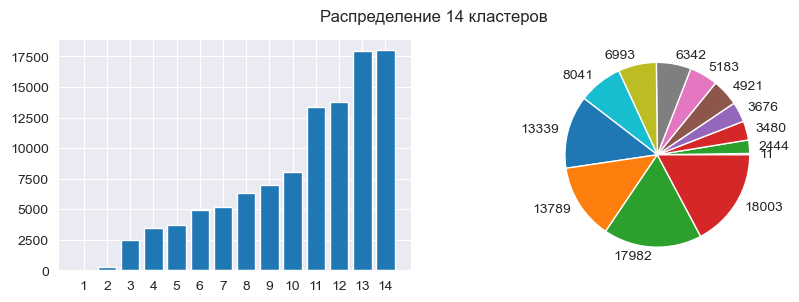

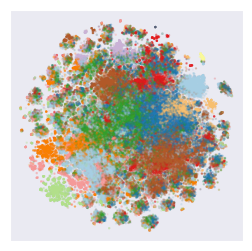

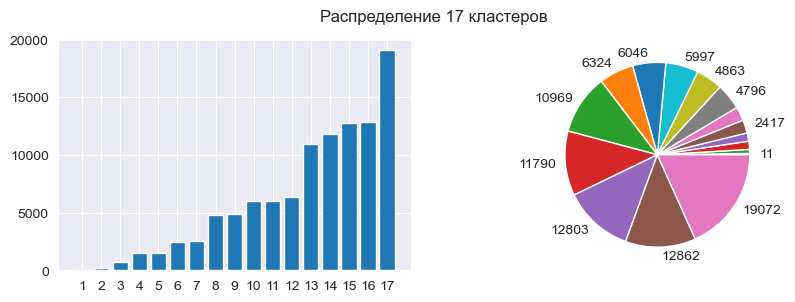

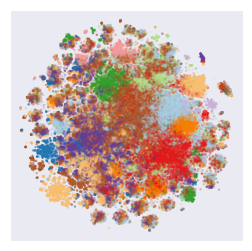

In [22]:
lable_list = []
for k in [9, 12, 14, 17]:
    cluster_pipe_kmeans = Pipeline([
        ('preprocessor', preprocess),
        ('clusterisator', KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=20,
            random_state=42
        ))
    ])

    lable_list += [cluster_pipe_kmeans.fit_predict(df_cluster)]
    labels_kmeans_sizes = np.sort(np.unique(lable_list[-1], return_counts=True)[1])
    (labels_kmeans_sizes / labels_kmeans_sizes.sum() * 100).round(1)

    _, ax = plt.subplots(1, 2, figsize=(10, 3))
    plt.suptitle(f'Распределение {k} кластеров')
    ax[0].bar(range(1, len(labels_kmeans_sizes) + 1), labels_kmeans_sizes)
    ax[0].set_xticks(range(1, labels_kmeans_sizes.size+1))
    # фильтр лейблов для графика типа "пирог", чтобы они не перекрывали друг друга
    mask = labels_kmeans_sizes < 3000
    mask[[0, int(mask.sum() // 1.33)]] = False
    ax[1].pie(labels_kmeans_sizes, labels=np.where(mask, '', labels_kmeans_sizes));

    IMG_FOLDER = 'report_images'
    file_name = f'cluster_distribution_{k}.png'
    full_path = os.path.join(BASE_DIR, IMG_FOLDER, file_name)
    plt.savefig(full_path)

    plt.figure(figsize=(3, 3))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=.5, alpha=.15, c=lable_list[-1], cmap='Paired')
    plt.xticks([])
    plt.yticks([])

    file_name = f'cluster_allocation_{k}.png'
    full_path = os.path.join(BASE_DIR, IMG_FOLDER, file_name)
    plt.savefig(full_path)

Итоговый выбор осуществлен на основании **бизнес-логики и распределения объемов кластеров**:
1.  **`k` = 9**: порождает слишком крупные (обобщенные) сегменты и имеет один крупный тяжеловесный кластер, внутри них могут смешаться клиенты с разными потребительскими психотипами, что в свою очередь может привести к потере персонализации и непригодности большинства кластеров.
2.  **`k` = 14, 17**: приводит к излишнему дроблению на микро-сегменты. Появляются кластеры с исчезающе малой долей клиентов (<1-2%), для которых нерентабельно запускать отдельные маркетинговые кампании. Слишком мелкие кластеры также нестабильны во времени, но могут быть интерпретированы как аномалии.
3.  **`k` = 12**: кажется более оптимальным балансом. В этой конфигурации K-Means выделяет достаточно крупные сегменты, чтобы быть коммерчески привлекательными.

In [23]:
# корректировка нумерации кластеров таким образом, чтобы кластеры с бо́льшим объемом имели бо́льший номер
# 1. Создание карты подмены номеров
labels = lable_list[1]
idx, lbs_count = np.unique(labels, return_counts=True)
new_labels_map = dict(zip(lbs_count.argsort().tolist(), (idx + 1).tolist()))
new_labels_map, lbs_count

({4: 1, 5: 2, 2: 3, 7: 4, 8: 5, 3: 6, 1: 7, 9: 8, 10: 9, 0: 10, 6: 11, 11: 12},
 array([12829,  7767,  4087,  6720,   233,  2716, 13408,  5327,  5784,
        10336, 10776, 24454]))

In [24]:
# 2. Добавление кластеров в датасет df_cluster и последующая подмена номеров кластеров в нем
df_cluster['cluster'] = labels
df_cluster['cluster'] = df_cluster['cluster'].map(new_labels_map)
df_cluster['cluster'].value_counts()

cluster
12    24454
11    13408
10    12829
9     10776
8     10336
7      7767
6      6720
5      5784
4      5327
3      4087
2      2716
1       233
Name: count, dtype: int64

In [25]:
# сохранение итогового файла df_cluster
file_name = 'df_cluster.csv'
full_path = os.path.join(BASE_DIR, DATA_FOLDER, file_name)
df_cluster.to_csv(full_path)

### Вспомогательный набор артефактов для интерпретации кластеров

Для перевода математического результата в язык понятных бизнес-метрик разработан программный пайплайн, состоящий из трех функций:

#### 1. `analysis_constructor(df, feature_list, threshold=0.15)`
**Назначение:** Формирует «Отпечаток» (Fingerprint) кластера по количественным признакам (деньги, частота, скидки).
**Логика работы (Анализ относительного среднего):**
Вместо того чтобы показывать голые цифры (например, "средний чек 2500"), функция сравнивает среднее значение признака внутри каждого кластера с *максимальным* и *минимальным* средним значением этого признака среди *всех* кластеров.
*   Если метрика кластера находится в верхних 15% (по умолчанию `threshold=.15`) от глобального максимума, признаку присваивается тег **'high'** (Выражено ярко).
*   Если метрика падает в нижние 15%, присваивается тег **'low'** (Выражено слабо).
*   Остальные (средние) значения скрываются знаком **'-'**, чтобы не отвлекать внимание.
*В результате отличительные черты каждой группы прослеживаются явным образом.*

#### 2. `analysis_constructor_categorical(df, category, rank=25)`
**Назначение:** Оценивает предпочтения кластера по категориальным признакам (Любимые Бренды, Цвета, Категории товаров).
**Логика работы:**
Поскольку среднее значение для категориальных переменных не посчитать, функция работает через **долевое распределение (Share)** категорий каждого признака. Она:
1. Вычисляет топ-`rank` (по умолчанию, топ-25) самых популярных категорий внутри признака (брендов, наименований продукта) в кластере.
2. Считает долю (в %) каждой из `rank` (25 по умолчанию) категории категориального признака для каждого кластера (Например: для кластера 1 - кроссовки 0.2, футболки 0.1 и т.д, для кластера 2 - кроссовки 0.3, брюки 0.05 и т.д).
3. Точно так же, как и предыдущая функция, применяет пороговый фильтр: если бренд доминирует в покупках кластера по сравнению с другими кластерами, ставится тег **'high'** (например для кластера 1 футболки получат тег **'high'**, а для кластера 2 - кроссовки).

#### 3. `cluster_description(df, sep='all')`
**Назначение:** Функция предназначена для презентации итогового результата. Форматирует данные для итоговых таблиц и отчетов.
**Логика работы:**
Берет громоздкие DataFrame-матрицы, полученные из `analysis_constructor`, убирает неинформативные прочерки (`'-'`), осуществляет сворачивание и объединяет признаки в компактный строковый формат вида `[Признак: Значение]`. Выдает очищенный, готовый к бизнес-презентации профиль маркетинг-сегмента, на котором строится описание профайла кластера


In [26]:
df_cluster_total = pd.DataFrame(columns=['cluster', 'value'])

In [27]:
def analysis_constructor(df, feature_list, threshold=.15):
    df_grouped = (
    df[['cluster'] + feature_list]
    .groupby(['cluster'])
    .mean()
    )

    mx_df = df_grouped.max().to_frame().T.round(3).rename(index={0:'max'})
    mn_df = df_grouped.min().to_frame().T.round(3).rename(index={0:'min'})
    # выделение значимых величин в категории low и high для понятного восприятия
    for col in df_grouped.columns:
        mx = df_grouped[col].max()
        mask_high = df_grouped[col] >= mx*(1-threshold)
        #mask_low = df_grouped[col] <= mx*(1 + threshold)
        mask_low = df_grouped[col] <= mx*threshold

        df_grouped[col] = '-'
        df_grouped.loc[mask_high, col] = 'high'
        df_grouped.loc[mask_low, col] = 'low'
        df_grouped.index.name = 'cluster'

    return pd.concat([df_grouped, mx_df, mn_df]).T

In [28]:
def cluster_description(df, sep='all'):
    df = df.T
    if sep == 'all':
        mask = (df == '-') | (df == '')
    else:
        mask = (df == '-')

    if df.columns.name == None:
        nm = ''
    else:
        nm = df.columns.name
    df = df.mask(~mask, nm + ': ' + df.columns + '-' + df).mask(mask, np.nan)
    df_melted = df.reset_index().melt('cluster')
    return df_melted[df_melted['value'].notna()][['cluster', 'value']].sort_values('cluster').reset_index(drop=True)

In [29]:
#dfs = [df_cluster_color, df_cluster_color_modif, df_cluster_discount, df_cluster_prod_gender, df_cluster_entrop, df_cluster_cat, df_cluster_coeffs]
mask = df_cluster_color_modif.columns.str.contains('mean')
feature_list = df_cluster_color_modif.columns[mask].tolist()

df_an = analysis_constructor(df_cluster, feature_list)
df_an.columns.name = 'cluster'
df_an.index.name = 'modificator'

df_cluster_total = pd.concat([
    df_cluster_total, cluster_description(df_an.drop(columns=['max', 'min']), sep='all')
], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12,max,min
modificator,,,,,,,,,,,,,,
is_bright_mean,-,-,low,-,-,-,high,-,-,low,low,-,0.268,0.007
is_dark_mean,-,-,low,-,-,-,-,high,-,high,-,-,0.607,0.011
is_iridescent_mean,low,-,low,-,low,low,high,-,low,low,-,-,0.0,0.0
is_light_mean,-,-,low,-,-,-,-,-,high,-,-,-,0.557,0.016
is_multicolored_mean,low,low,low,high,low,low,low,low,low,low,low,low,0.299,0.003
is_neutral_mean,-,-,low,-,-,-,-,-,-,high,-,-,0.907,0.012
is_pastel_mean,-,low,low,-,-,-,-,low,high,low,low,low,0.236,0.007
is_rare_mean,-,-,high,-,-,-,-,-,-,low,high,-,0.003,0.0
is_saturated_mean,-,-,low,-,-,-,high,high,-,low,low,-,0.578,0.025


In [30]:
#dfs = [df_cluster_color, df_cluster_color_modif, df_cluster_discount, df_cluster_prod_gender, df_cluster_entrop, df_cluster_cat, df_cluster_coeffs]
feature_list = df_cluster_discount.columns.tolist()

df_an = analysis_constructor(df_cluster, feature_list)
df_an.columns.name = 'cluster'
df_an.index.name = 'purchases'

df_cluster_total = pd.concat([
    df_cluster_total, cluster_description(df_an.drop(columns=['max', 'min']), sep='all')
], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12,max,min
purchases,,,,,,,,,,,,,,
n_purchases,-,-,low,-,high,-,low,low,-,low,-,-,32.866,3.038
cost_sum,-,high,low,low,high,low,low,low,-,low,-,-,169770.18,15292.048
cost_mean,-,high,-,low,low,low,low,low,low,-,-,-,35155.029,3264.282
avg_basket_money,-,high,low,low,-,low,-,low,-,-,-,-,44983.16,4887.443
avg_basket_quant,-,-,-,-,high,-,-,-,-,-,-,-,2.558,1.099
cost_std,low,high,low,low,low,low,low,low,low,low,low,low,38501.928,2474.984
base_sale_mean,high,-,low,-,high,high,-,-,high,-,-,-,0.472,0.023
base_sale_sum,-,low,low,low,high,-,low,low,-,low,low,-,14.384,0.109
cost_fp_mean,low,high,-,low,low,low,low,low,low,low,low,low,33170.711,2240.504


In [31]:
#dfs = [df_cluster_color, df_cluster_color_modif, df_cluster_discount, df_cluster_prod_gender, df_cluster_entrop, df_cluster_cat, df_cluster_coeffs]
feature_list  = df_cluster_prod_gender.columns.tolist()

df_an = analysis_constructor(df_cluster, feature_list)
df_an.columns.name = 'cluster'
df_an.index.name = 'product_gender'

df_cluster_total = pd.concat([
    df_cluster_total, cluster_description(df_an.drop(columns=['max', 'min']), sep='all')
], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12,max,min
product_gender,,,,,,,,,,,,,,
prod_adults,high,-,high,-,high,-,-,-,high,high,high,high,0.724,0.205
prod_kids,-,low,low,-,low,high,low,-,-,low,low,low,0.662,0.031
prod_men,high,-,high,-,-,-,-,-,-,high,high,high,0.477,0.084
prod_women,-,low,-,-,-,-,-,-,high,-,-,-,0.557,0.058
prod_boys,low,low,low,low,low,high,low,-,low,low,low,low,0.386,0.011
prod_girls,-,low,-,-,-,high,low,low,-,low,low,low,0.181,0.004


In [32]:
#dfs = [df_cluster_color, df_cluster_color_modif, df_cluster_discount, df_cluster_prod_gender, df_cluster_entrop, df_cluster_cat, df_cluster_coeffs]
feature_list  = df_cluster_entrop.columns.tolist()

df_an = analysis_constructor(df_cluster, feature_list)
df_an.columns.name = 'cluster'
df_an.index.name = 'product_entropies'

df_cluster_total = pd.concat([
    df_cluster_total, cluster_description(df_an.drop(columns=['max', 'min']), sep='all')
], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12,max,min
product_entropies,,,,,,,,,,,,,,
product_name_entropy,-,-,-,-,high,-,-,-,-,-,-,-,2.423,0.622
product_brand_entropy,-,-,-,-,high,-,-,-,-,-,-,-,2.061,0.577
basic_colour_entropy,-,-,low,-,high,-,-,-,-,-,-,-,1.841,0.125
day_of_week_entropy,-,-,-,-,high,-,-,-,-,-,-,-,1.534,0.604


In [33]:
#dfs = [df_cluster_color, df_cluster_color_modif, df_cluster_discount, df_cluster_prod_gender, df_cluster_entrop, df_cluster_cat, df_cluster_coeffs]
mask = df_cluster_cat.columns.str.contains('basic_colour')
feature_list  = df_cluster_cat.columns[mask].tolist()

df_an = analysis_constructor(df_cluster, feature_list)
df_an.columns.name = 'cluster'
df_an.index.name = 'basic_colour'

df_cluster_total = pd.concat([
    df_cluster_total, cluster_description(df_an.drop(columns=['max', 'min']), sep='all')
], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12,max,min
basic_colour,,,,,,,,,,,,,,
basic_colour_black,-,-,low,-,-,-,-,-,-,high,-,-,0.414,0.001
basic_colour_blue,-,low,low,low,-,-,low,high,low,low,low,-,0.377,0.0
basic_colour_brown,-,-,-,-,-,-,high,-,-,low,-,high,0.041,0.005
basic_colour_colour_block,-,-,low,-,-,high,-,-,-,high,-,-,0.318,0.01
basic_colour_gray,-,high,low,-,-,-,-,-,-,high,-,-,0.099,0.005
basic_colour_green,-,-,low,-,-,-,high,-,-,low,low,-,0.205,0.001
basic_colour_multicolor,low,low,low,high,low,low,low,low,low,low,low,low,0.297,0.001
basic_colour_orange,-,-,low,low,-,low,high,low,low,low,low,low,0.074,0.0
basic_colour_pink,-,low,low,-,-,-,-,low,high,-,low,-,0.294,0.01


In [34]:
print('доля базового цвета среди всех покупок, %:')
df_purchases['basic_colour'].value_counts(normalize=True).to_frame().round(4)*100

доля базового цвета среди всех покупок, %:


,proportion
basic_colour,
black,21.57
colour_block,17.77
unknown,15.37
pink,8.48
blue,8.24
gray,6.40
white,5.69
green,5.12
brown,2.46


In [35]:
feature_list = ['id', 'product_name', 'product_brand', 'cost', 'base_sale', 'cost_fp',
                'cost_md', 'colour_eng', 'basic_colour', 'gender']
df_product_an = pd.merge(df_purchases[feature_list], df_cluster['cluster'].reset_index(), on='id')
df_product_an

,id,product_name,product_brand,cost,base_sale,cost_fp,cost_md,colour_eng,basic_colour,gender,cluster
0,0,велосипед,stern,13599,1,0,13599,white/blue,colour_block,0.0,7
1,0,стол,outventure,1499,0,1499,0,green,green,0.0,7
2,0,набор,outventure,4799,0,4799,0,beige,pink,0.0,7
3,3,бутсы,gsd,1599,0,1599,0,white,white,1.0,4
4,3,мяч,puma,7199,0,7199,0,multicolor,multicolor,1.0,4
...,...,...,...,...,...,...,...,...,...,...,...
780112,178004,полуботинки,ascot,7999,0,7999,0,khaki/black,colour_block,1.0,12
780113,178004,кроссовки,nike,24299,0,24299,0,black/grey,colour_block,1.0,12
780114,178004,кроссовки,nike,24299,0,24299,0,black/grey,colour_block,1.0,12
780115,178004,пакет,noname,12,0,12,0,brown,brown,1.0,12


In [36]:
# analysis_constructor_categorical(df_product_an, feature_list)
def analysis_constructor_categorical(df, category, rank=25):
    df_gr = (
        df
        .groupby(['cluster', category])
        .size()
        #.agg({'cost':'count'})
        .reset_index()
        .rename(columns={0: 'share'})
        .sort_values(['cluster', 'share'], ascending=[True, False], ignore_index=True)
    )


    df_gr['share'] = (df_gr['share'] / df_gr.groupby(['cluster'])['share'].transform('sum') * 100).round(2)
    df_gr['rank'] = df_gr.groupby('cluster')['share'].rank(method='first', ascending=False)

    df_gr_20 = df_gr[df_gr['rank'] <= rank]

    df_gr_20 = (
        pd.crosstab(
        index=df_gr_20[category],
        columns=df_gr_20['cluster'],
        values=df_gr_20['share'],
        aggfunc='sum',
        margins=True
        )
        #.fillna(0)
        .drop('All', axis=0)
        .sort_values('All', ascending=False)
        .drop('All', axis=1)
        .T
    )

    df_gr_ranked = df_gr_20.copy()

    threshold = .1
    for col in df_gr_20.columns:
        mask_high = df_gr_20[col] >= df_gr_20[col].max() * (1-threshold)
        mask_low = df_gr_20[col] <= df_gr_20[col].max() * threshold
        mask_nan = df_gr_20[col].isna()
        df_gr_20[col] = '-'
        df_gr_20.loc[mask_nan, col] = ''
        df_gr_20.loc[mask_high, col] = 'high'
        df_gr_20.loc[mask_low, col] = 'low'

    return df_gr_20.T

In [37]:
df_an = analysis_constructor_categorical(df_product_an, 'product_name')

df_cluster_total = pd.concat([df_cluster_total, cluster_description(df_an)], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12
product_name,,,,,,,,,,,,
кроссовки,-,-,-,-,-,-,-,-,-,high,high,-
брюки,-,-,-,-,-,-,-,high,-,-,-,-
футболка,-,-,-,-,high,high,-,-,-,-,-,-
кеды,-,-,-,-,-,-,-,-,-,high,-,-
полуботинки,-,-,high,-,-,-,-,-,-,-,-,-
шорты,-,-,-,-,-,-,-,high,-,-,-,-
куртка,high,-,-,-,-,-,-,-,-,-,-,-
велосипед,low,high,low,low,low,low,low,low,low,-,low,low
сандалии,-,-,-,-,-,high,-,-,high,-,-,-


In [38]:
df_an = analysis_constructor_categorical(df_product_an, 'product_brand')

df_cluster_total = pd.concat([df_cluster_total, cluster_description(df_an)], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12
product_brand,,,,,,,,,,,,
demix,-,-,-,-,-,high,-,-,-,-,-,-
outventure,-,-,-,-,-,-,high,-,-,-,-,-
fila,-,-,-,-,-,high,-,-,-,-,-,-
puma,-,-,-,-,-,-,-,-,-,high,high,-
columbia,high,-,-,-,-,low,-,-,-,-,-,-
nike,-,-,-,-,-,-,-,-,-,high,-,-
northland,-,-,-,-,high,-,high,-,-,-,-,-
termit,high,,-,high,-,-,-,-,-,-,-,-
stern,low,high,low,-,-,-,-,low,-,-,-,-


In [39]:
df_an = analysis_constructor_categorical(df_product_an, 'gender') # colour_eng
df_an.index = ['men', 'women']

df_cluster_total = pd.concat([df_cluster_total, cluster_description(df_an)], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12
men,-,high,-,-,-,-,-,-,-,-,-,-
women,-,-,-,-,-,high,-,-,high,-,-,-


In [40]:
df_an = analysis_constructor_categorical(df_product_an, 'colour_eng', rank=20)

df_cluster_total = pd.concat([df_cluster_total, cluster_description(df_an)], axis=0, ignore_index=True)

df_an

cluster,1,2,3,4,5,6,7,8,9,10,11,12
colour_eng,,,,,,,,,,,,
unknown,-,-,high,-,-,-,-,-,-,low,-,-
black,-,-,low,-,-,-,-,-,-,high,-,-
white,-,-,low,-,-,-,-,-,high,high,-,-
blue,-,-,low,-,-,-,-,high,low,,,-
dark-blue,-,-,low,-,-,-,-,high,low,,,-
multicolor,-,low,low,high,-,low,low,low,low,,low,low
grey,-,high,-,-,-,-,-,-,-,high,-,-
beige,-,-,low,-,-,-,-,-,high,-,-,-
green,-,-,low,-,-,-,high,-,-,,low,-


### Характеристики кластеров

#### Кластер 12 (Численность ~ 20 000)
**Потребительский профиль:**

    - предпочитает покупать недорогие товары по полной стоимости
    - к скидкам нечувствителен
    - ориентированы на взрослый ассортимент - товаров для себя, товаров для мужчин (особенно избегают детских товаров для девочек)
    - товарная корзина состоит из одежды, топов продаж, без особого акцента на какой-либо тип
    - распределение брендов подчиняется аналогичному закону
        - при этом наблюдается акцент на бренд Kappa и Asics в сравнении с другими кластерами
    - из аксессуаров любят кепки (бейсболки)
    - цветовые предпочтения не выражены структурно и являются скорее консервативными:
        - есть склонность к коричневым оттенкам (однако она относительна и превалирует только в сравнении с другими кластерами)
        - не любит многоцветность, пестроту или что-то экспериментальное
        - также не проявляют интерес к оттенкам синего, желтого и оранжевого

**Итог:** кластер в целом проявляет признаки, свойственные масс-маркету, не требует какого-либо индивидуального подхода, мужчины, предпочитающие практичные тона и цветовые оттенки, простую спортивную повседневную одежду, нечастые (но постоянные) посетители с низким уровнем вовлечения, при этом одновременно легко удерживаемый тип покупателя, имеющий средние предсказуемые предпочтения, которые будут повторяться от покупки к покупке

**Рекомендации:** применять ценовую  политику типа масс маркет на одежду для взрослых (скидки на базовые комплекты, базовые луки по типу 3 по цене 2 и тп), поддерживать ассортимент базовой одежды для взрослых (в особенности, для мужчин), в презентации товара придерживаться сдержанных слоганов с акцентом на универсальность товара (подойдет ко всему)

In [41]:
df_cluster_total[df_cluster_total['cluster'] == 12]

,cluster,value
63,12,modificator: is_multicolored_mean-low
64,12,modificator: is_texture_mean-low
65,12,modificator: is_pastel_mean-low
66,12,modificator: is_uncertain_mean-low
153,12,purchases: cost_fp_mean-low
154,12,purchases: cost_std-low
190,12,product_gender: prod_men-high
191,12,product_gender: prod_kids-low
192,12,product_gender: prod_adults-high
193,12,product_gender: prod_boys-low


#### Кластер 11 (Численность ~ 19 000)
**Потребительский профиль:**

    - предпочитает покупать недорогие товары в целом
    - предпочитают не насыщать корзину дополнительными товарами
    - к скидкам нечувствителен
    - ориентированы на детский ассортимент (присутствует акцент на товары для мальчиков)
    - товарная корзина состоит из одежды, топов продаж, присутствует акцент на футболки, бейсболки, ветровки
    - распределение брендов имеет аналогичную тенденцию
        - при этом наблюдается акцент на внутренние бренд Demix и бренд Fila в сравнении с другими кластерами
    - цветовые предпочтения не выражены структурно и являются скорее консервативными:
        - есть склонность к красным оттенкам (однако она относительна и превалирует только в сравнении с другими кластерами)
        - не любит многоцветность, пестроту или что-то экспериментальное
        - также не проявляют интерес к оттенкам желтого и оранжевого

**Итог:** кластер в целом проявляет признаки, свойственные масс-маркету с акцентом на товары для детей по доступной цене и особенным вниманием к детским, но не пестрые цветам - скорее для того, чтобы одеть ребенка, чем выделить его - практичную базовую одежду для физкультуры и физической активности

**Рекомендации:** применять ценовую политику типа масс-маркет для товаров для детей, выделять базовые спортивные продукты (футболки, брюки, кепки, ветровки), подчеркивать долговечность, комфорт, легкий уход и возможность получить скидку за бóльшую партию покупки, предлагать промо на комплекты, создавать предложения на количество по спец ценам, подарочные варианты, начало спортивных сезонов.

In [42]:
df_cluster_total[df_cluster_total['cluster'] == 11]

,cluster,value
57,11,modificator: is_rare_mean-high
58,11,modificator: is_texture_mean-low
59,11,modificator: is_pastel_mean-low
60,11,modificator: is_bright_mean-low
61,11,modificator: is_saturated_mean-low
62,11,modificator: is_multicolored_mean-low
149,11,purchases: base_sale_sum-low
150,11,purchases: cost_fp_mean-low
151,11,purchases: cost_md_sum-low
152,11,purchases: cost_std-low


#### Кластер 10 (Численность ~ 10 000)
**Потребительский профиль:**

    - предпочитает покупать дешевые товары со скидкой
    - предпочитают не насыщать корзину дополнительными товарами
    - максимальная чувствительность к скидкам (проявляют активность в момент скидок и интерес к товарам по скидкам)
    - в основном - это женщины
    - ориентированы на одежду (не аксессуары) как для взрослых, так и для детей одинаково сильно
    - товарная корзина состоит из одежды, топов продаж, присутствует акцент на футболки, свитшоты, обувь, слипоны, легинсы
    - предпочитают топовые бренды,
        - при этом наблюдается акцент на внутренний бренд Demix, а также Kappa, GSD, Geox, Protest в сравнении с другими кластерами
    - цветовые предпочтения имеют пастельную направленность со склонностью к женским тонам:
        - розовым, персиковым, голубым, светло-зеленым, сливочным, бежевым
        - не любит многоцветность
        - также не проявляют интерес к оттенкам желтого и темно синего

**Итог:** кластер проявляет признаки охотника за распродажами товаров, имеет предпочтение в цветах пастельного типа, семейно ориентирован, ориентированы на стиль, но в слабой мере с легким кажуальным уклоном

**Рекомендации:** кластер очень полезен при распродажах и необходимости избавиться от залежавшихся остатков товара, которые необходимо распродать для обновления коллекций и освобождения от стоков. посыл должен быть ориентирован на легкую текстурность, повседневный комфорт и удобство, нежные цвета. отлично подойдут кросс промо отвечающие условию мама-ребенок, семейные комбинации одежды для отдыха; скидки, направленные на цветовые акцент


In [43]:
df_cluster_total[df_cluster_total['cluster'] == 10]

,cluster,value
46,10,modificator: is_saturated_mean-low
47,10,modificator: is_bright_mean-low
48,10,modificator: is_uncertain_mean-low
49,10,modificator: is_dark_mean-high
50,10,modificator: is_iridescent_mean-low
...,...,...
509,10,colour_eng: grey-high
510,10,colour_eng: white-high
511,10,colour_eng: grey/white-high
512,10,colour_eng: white/black-high


#### Кластер 9 (Численность ~ 10 000)
**Потребительский профиль:**

    - кластер с очень низкой покупательской способностью
    - предпочитает покупать дешевые товары в маленьком количестве при наличии необходимости
    - не чувствительны к скидкам
    - предпочитают максимально упрощать товарную корзину
    - предпочитают простоту
    - ориентированы на товары для мужчин, взрослых (как одежду, так и аксессуары/оборудование)
    - товарная корзина состоит из одежды, топов продаж, присутствует акцент на сумки, костюмы, бейсболки
    - при этом наблюдается акцент на внутренний бренд Demix, и недорогие бренды GSD, Kappa
    - цветовые предпочтения отличаются максимальной простотой:
        - темные нейтральные тона
        - цвет - черный, оттенки серого
        - игнорирует любые цветовые расхождения с нейтральными тонами (не является цветочусвтвительным)

**Итог:** кластер проявляет признаки ригидности (неизменчивость стиля, предсказуемый ординарный вкус) в отношении товара и максимальной простоты/минимализма, простого дизайна с акцентом на функциональность, универсальность и кажуальность

**Рекомендации:** в маркетинговой политике направить акцент на товары нейтральных темных тонов и кросс-промо (очень хорошо отвечает потребностям, обусловленным практичностью), проводить сдержанную политику скидок


In [44]:
df_cluster_total[df_cluster_total['cluster'] == 9]

,cluster,value
40,9,modificator: is_texture_mean-low
41,9,modificator: is_uncertain_mean-low
42,9,modificator: is_pastel_mean-high
43,9,modificator: is_iridescent_mean-low
44,9,modificator: is_light_mean-high
45,9,modificator: is_multicolored_mean-low
136,9,purchases: cost_sum_md_share-high
137,9,purchases: cost_mean_md_vs_fp-high
138,9,purchases: cost_std-low
139,9,purchases: cost_mean-low


#### Кластер 8 (Численность ~ 10 000)
**Потребительский профиль:**

    - кластер с очень низкой покупательской способностью
    - предпочитает покупать дешевые товары в маленьком количестве при наличии необходимости
    - не чувствительны к скидкам
    - предпочитают максимально упрощать товарную корзину
    - предпочитают простоту
    - ориентированы на ассортимент для мужчин, взрослых
    - товарная корзина имеет смещение акцента на обувь (ботинки, полуботинки)
    - при этом наблюдается повышенный акцент на бренды Skechers, Merrell, Salomon, Bona
    - цветовые предпочтения неопределены по оттенку, однако не тяготеет к разноцветным палитрам:
        - цветовые предпочтения плохо идентифицируются в силу отсутствия ярко выраженного цветового признака в описании продукта покупки

**Итог:** кластер проявляет признаки практичности, движим скорее необходимостью в отношении покупок, склонен к покупкам обуви

**Рекомендации:** в маркетинговой политике направить акцент на обувь и практическую ценность: надежность, комфорт, долгую службу продукта, безопасность и защиту от воздействий окружающей среды (дождь, морозы и тп). Вполне могут сработать кросс промо с товарами/аксессуарами, имеющими схожие характеристики: амортизирующие стельки, функциональные носки, средства ухода, продлевающие сроки эксплуатации, водоотталкивающие спреи и мази и тп. Для них могут сработать ненавязчивые напоминания о необходимости обновить старый изношенный продукт или с информацией о появлении улучшенной модели, сезонных аксессуарах и средствах ухода


In [45]:
df_cluster_total[df_cluster_total['cluster'] == 8]

,cluster,value
34,8,modificator: is_pastel_mean-low
35,8,modificator: is_texture_mean-low
36,8,modificator: is_uncertain_mean-low
37,8,modificator: is_dark_mean-high
38,8,modificator: is_multicolored_mean-low
39,8,modificator: is_saturated_mean-high
128,8,purchases: avg_basket_money-low
129,8,purchases: cost_std-low
130,8,purchases: cost_mean-low
131,8,purchases: cost_sum-low


#### Кластер 7 (Численность ~ 7 000)
**Потребительский профиль:**

    - кластер с редкой покупательской активностью и невысокой покупательской способностью
    - предпочитает покупать дешевые товары в маленьком количестве
    - не чувствительны к скидкам
    - предпочитают максимально упрощать товарную корзину
    - нет выраженного гендерного акцента на товары или акцента на возрастной тип товара
    - товарная корзина имеет смещение акцента на outdoor аксессуары или экипировку (мяч, коврик, ветровка, рюкзак, палатка)
    - наблюдается повышенный акцент на соответствующие профильные бренды бренды wilson, outventure, head, northland
    - цветовые предпочтения выражены склонностью к ярким/пестрым оттенкам:
        - среди цветов часто встречаются желтый, зеленый, оранжевый, коричневый

**Итог:** кластер не проявляет признаки активности в отношении продаж (трудно удержать) и склонен к приобретению товаров для активного отдыха, ему важна функциональность и безопасность (возможность быть увиденным/найденным в чрезвычайных ситуациях)

**Рекомендации:** в маркетинговой политике направить акцент на товары для активного отдыха и созданию семейства/коллекций товаров для активного отдыха и наборы, избегать неярких цветов при закупках и предложении. Важно делать акцент на сезонности(открытие походного периода и тп)/наличии долгих выходных/праздников при составлении промо


In [46]:
df_cluster_total[df_cluster_total['cluster'] == 7]

,cluster,value
28,7,modificator: is_bright_mean-high
29,7,modificator: is_iridescent_mean-high
30,7,modificator: is_multicolored_mean-low
31,7,modificator: is_texture_mean-low
32,7,modificator: is_uncertain_mean-low
33,7,modificator: is_saturated_mean-high
121,7,purchases: cost_mean-low
122,7,purchases: cost_fp_mean-low
123,7,purchases: base_sale_sum-low
124,7,purchases: cost_std-low


#### Кластер 6 (Численность ~ 6 000)
**Потребительский профиль:**

    - кластер с не очень высокой покупательской активностью в особенности в сезон полной стоимости
    - предпочитает покупать недорогие товары в небольшом количестве
    - средняя чувствительность к скидкам
    - в покупках сделан акцент на  товары для мужчин, ассортимент товаров для взрослых
    - среди товаров наблюдается акцент на обувь: кеды, кроссовки, сабо, а также самокаты
    - особенный акцент в покупках смещен на топовые (известные бренды) Nike, Puma, Adidas, Reebook и тд
    - цветовые предпочтения:
        - нейтральные светлые тона в составе цветового блока
        - при этом избегают проявления текстурности в расветке (принты, горошек, полоски и тп)
        - среди цветов часто встречаются белый, светло-серый, сливочный
        - черный предпочитают только в сочетании со светлыми цветами в цветовом блоке
        - наиболее популярные цветовые блоки белого с:
            - голубым
            - сливочным
            - светло-серым
            - красным
            - розовым


**Итог:** кластер проявляет признаки активности при скидках, предпочитает цветовые сочетания с акцентом на белый цвет, товары раскрученных брендов, в покупках делается акцент на товары для мужчин (и/или для взрослых); сфокусирован на том, как товар выглядит, что о нем скажут окружающие и какой это создаст имидж. Средний вариант между атлетам и охотниками за скидками.

**Рекомендации:** в маркетинговой политике направить акцент на индивидуальные скидки на популярные бренды и светлые тона (лучше сочетания белым как основного), релизы новых моделей обуви, лимитированные коллекции, сезонные коллекции - все, что связано со стилем и дизайном. Очень полезно для них создавать лукбуки, фэшен-гайды, сочетание и комбинаций с применением целевого продукта, рекомендации по total look. В этой связи, клиенты данного кластера очень подходят для кросс предложений: брюк, футболок, худи и прочей одежды, аксессуаров, максимально соответствующим обуви по цветовому балансу, сезонных предложений, особых имиджевых членских (внутренних/закрытых) предложений для подержания лояльности. Однако, уровень скидок должен быть контролируемым/сдержанным (учитывая особенности кластера)


In [47]:
df_cluster_total[df_cluster_total['cluster'] == 6].iloc[1:, :]

,cluster,value
25,6,modificator: is_colour_block_mean-high
26,6,modificator: is_multicolored_mean-low
27,6,modificator: is_texture_mean-low
113,6,purchases: cost_sum-low
114,6,purchases: cost_sum_md_share-high
115,6,purchases: cost_md_sum-low
116,6,purchases: avg_basket_money-low
117,6,purchases: cost_fp_mean-low
118,6,purchases: cost_std-low
119,6,purchases: base_sale_mean-high


#### Кластер 5 (Численность ~ 5 600)
**Потребительский профиль:**

    - кластер с очень высокой покупательской активностью во время распродажи
    - очень чувствителен к скидкам
    - предпочитает покупать дешевые товары в большом количестве (максимально наполнять корзину)
    - в покупках отдается предпочтение товарам для взрослых, но высокие покупки и других категорий (можно говорить о семейном акценте)
    - в категориальных предпочтениях проявляет максимальное разнообразие (семейность, цветовые предпочтения, продуктовые предпочтения, бренды)
    - среди товаров наблюдается акцент на одежду (футболки, куртки, толстовки и пр), а не на оборудование или аксессуары

**Итог:** кластер проявляет очень чувствителен к скидкам и максимально нацелен на них, при этом не придирчив в типах и назначении одежды равно как и брендах. Это охотники за хорошей сделкой, расчетливы и дальновидны.

**Рекомендации:** это основной промо движимый сегмент, в маркетинговой политике направить акцент на индивидуальные скидки на товары - аутсайдеры продаж, при этом им отлично подходит тип спонтанного промо, ограниченными временными рамками: только сегодня, последние два дня; они отлично реагируют на почтовые рассылки, баннеры, пуш уведомления и тп; а также промо на отдельные группы товаров (таргет-промо): отдельно брюки, отдельно рубашки и тп. Нацелены на общую выгоду: скидка 1000 при покупке от 10000 и тп, лесенки, скидки на комплекты. Им подойдут бонусные промо для удержания лояльности.


In [48]:
df_cluster_total[df_cluster_total['cluster'] == 5]

,cluster,value
20,5,modificator: is_texture_mean-low
21,5,modificator: is_multicolored_mean-low
22,5,modificator: is_iridescent_mean-low
23,5,modificator: is_uncertain_mean-low
99,5,purchases: cost_std-low
100,5,purchases: base_sale_sum-high
101,5,purchases: cost_mean-low
102,5,purchases: cost_fp_mean-low
103,5,purchases: avg_basket_quant-high
104,5,purchases: base_sale_mean-high


#### Кластер 4 (Численность ~ 5 200)
**Потребительский профиль:**

    - кластер со средней покупательской активностью, но низкой покупательской способностью
    - предпочитает покупать товары со скидкой в небольшом количестве (практичный тип покупателя)
    - имеет чувствительность к скидкам
    - предпочитают упрощать товарную корзину
    - ориентированы на ассортимент для всей семьи
    - товарная корзина имеет высокую долю продаж коньков, носки, наборов
    - среди предпочтений по брендам относительно других кластеров можно выделить масс маркет марки: reaction, forsio, protest, demix, torneo, termit, kappa
    - цветовые предпочтения не выражены, наблюдается только акцент на мультицвет (смешанные цвета)

**Итог:** кластер проявляет интерес к базовым функциональным продуктам, имеет семейный акцент и повышенную относительную склонность к мультицвету, лоялен к непопулярным брендам, не готовый вкладываться в дорогостоящую продукцию. Отзовутся скорее на несложные/незамысловатые маркетинговые предложения. Покупают только то, что нужно по доступной для них цене.

**Рекомендации:** в маркетинговой политике направить акцент на товары неизвестных брендов сделать акцент на лучшей цене, скидки на повторные покупки (для удержания), при этом можно сделать акцент на визуальную цветовую игру и визуальное разнообразие, семейные наборы, мультинаборы. В этой связи, они могут быть полезны при распродажах в целях освобождения стоков. Акции для них лучше не усложнять условиями.


In [49]:
df_cluster_total[df_cluster_total['cluster'] == 4]

,cluster,value
18,4,modificator: is_texture_mean-low
19,4,modificator: is_multicolored_mean-high
92,4,purchases: base_sale_sum-low
93,4,purchases: avg_basket_money-low
94,4,purchases: cost_sum-low
95,4,purchases: cost_fp_mean-low
96,4,purchases: cost_mean-low
97,4,purchases: cost_md_sum-low
98,4,purchases: cost_std-low
166,4,product_gender: prod_boys-low


#### Кластер 3 (Численность ~ 4 800)
**Потребительский профиль:**

    - кластер со средней покупательской активностью и способностью
    - предпочитает покупать товары со скидкой в небольшом количестве и невысокой цене
    - строго ориентированы на ассортимент для детей
    - товарная корзина: высокую долю продаж имеют - ветровки, куртки, шлепанцы, сабо, рубашки, брюки, рюкзаки
    - среди предпочтений по брендам относительно других кластеров можно выделить mad, intex, columbia, fila, crocs
    - цветовые предпочтения: насыщенные и темные тона; цвета: пурпурные, красные, синие

**Итог:** кластер - родители, совершающие покупки не для себя, а проявляющие больше заботы для своих детей, не совершает много покупок, но готовые к повторным покупкам, ориентирован на забавные, интересные, необычные и часто заменяемые, но и практичные товары для детей

**Рекомендации:** сделать акцент на товары с цветовой насыщенностью с акцентом на визуальное восприятие, а не качество и результат выступления, смешанные наборы товаров в составе одной коллекции, но по-возможности сдержанные по цене (лучше дешевле материал, но визуально привлекательные продукты) - набор для плавания, забавные спортивные костюмы для физической культуры. Избегать одиночных представлений эксклюзивных товаров типа - премиальные шорты (без комплекта в виде футбоки/топа и тп) из высокотехнологичного материала для лучшего результата на тренировке. Хорошо подходят сезонные кампании: назад в школу, новогодний сет, начало летнего сезона и тп. Из промо подходят варианты скидок на комплекты: скидка на вторую вещь, лесенка 2-20%-3-30% и тп. Акцент в представлении товара - забавность, веселость, легкость, эмоциональность, движение. Избегать акцента на имиджевость, т.к. это не является потребностью данного кластера.


In [50]:
df_cluster_total[df_cluster_total['cluster'] == 3]

,cluster,value
6,3,modificator: is_bright_mean-low
7,3,modificator: is_multicolored_mean-low
8,3,modificator: is_uncertain_mean-high
9,3,modificator: is_light_mean-low
10,3,modificator: is_neutral_mean-low
...,...,...
458,3,colour_eng: black-low
459,3,colour_eng: multicolor-low
460,3,colour_eng: dark-blue-low
461,3,colour_eng: white-low


#### Кластер 2 (Численность ~ 2 500)
**Потребительский профиль:**

    - кластер с высокой покупательской способностью и высоким средним чеком
    - предпочитает товар по полной стоимости
    - слабо реагирует на скидки
    - имеет большой разброс в стоимости приобретаемой продукции
    - слабо ориентирован на ассортимент для детей и женщин
    - покупателями в основном являются мужчины
    - среди товаров превалирует спортивное оборудование и установки
    - цветовые предпочтения: оттенки серого, комбинации с черным

**Итог:** кластер спортсменов, инвестирующих в спорт (личный или на групповом/коллективном уровне), ориентированных на спортивное оборудование и полную стоимость, улучшение качества результатов, комфорта и безопасности, не склонные к дешевым альтернативам

**Рекомендации:** в маркетинговой политике направить акцент на профессиональное спортивное оборудование, новую коллекцию (новинки), качество, продуктивность, создать семейство вокруг продукта, который пользуется спросом у кластера (представлять экипировку, аксессуары для оборудования, дополнительные улучшающие элементы, запчасти, гарантии, страховки, помощь в ремонте и обслуживании - все, что сделает его эксплуатацию более комфортной и производительной), требуют индивидуальной работы с компетентными товарными экспертами и ценят отношение - ключевой сегмент для поддержания лояльности и долгосрочных отношений (применять реферальные промо для пришедших клиентов по их рекомендации в обмен на помощь в обслуживании и эксплуатации приобретенного оборудования).


In [51]:
df_cluster_total[df_cluster_total['cluster'] == 2]

,cluster,value
3,2,modificator: is_multicolored_mean-low
4,2,modificator: is_texture_mean-low
5,2,modificator: is_pastel_mean-low
73,2,purchases: cost_std-high
74,2,purchases: cost_mean-high
75,2,purchases: cost_fp_mean-high
76,2,purchases: avg_basket_money-high
77,2,purchases: base_sale_sum-low
78,2,purchases: cost_sum-high
79,2,purchases: cost_sum_md_share-low


#### Кластер 1 (Численность ~ 600)
**Потребительский профиль:**

    - кластер ориентирован на невысокую цену, одиночный товар
    - не выбирает между полной стоимостью и распродажей
    - полностью ориентирован на спортивные аксессуары и дополнения: очки, капы, аккумуляторы
    - цветовые предпочтения: не являются приоритетными

**Итог:** кластер ориентирован на аксессуары, является случайным (основное оборудование покупал у другого ритейлера), при этом покупает их целенаправленно (по необходимости при амортизации или в качестве улучшения/апгрейда к своему оборудованию)

**Рекомендации:** в маркетинговой политике направить акцент на ассортимент аксессуаров для каждого оборудования, продублировать лейаут ближе ко входу (чтобы привлечь случайного посетителя), обязательно сочетать с линейкой для апгрейда того оборудования, для которого предназначен аксессуар (например: очки для плавания - добавить жидкость предупреждающую запотевание очков), увеличить информацию о свойствах аксессуара в карточке продукта


In [52]:
df_cluster_total[df_cluster_total['cluster'] == 1]

,cluster,value
0,1,modificator: is_texture_mean-high
1,1,modificator: is_multicolored_mean-low
2,1,modificator: is_iridescent_mean-low
67,1,purchases: cost_std-low
68,1,purchases: base_sale_mean-high
69,1,purchases: cost_fp_mean-low
70,1,purchases: cost_sum_md_share-high
71,1,purchases: cost_md_mean-high
72,1,purchases: count_md_vs_fp-high
155,1,product_gender: prod_adults-high
